## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)

os.makedirs('artifacts', exist_ok=True)

## 2. Load Data

Dataset A pisah: `A.csv` berisi fitur, `A_targets.csv` berisi target. Digabung via `Student_ID`.

In [2]:
features = pd.read_csv('A.csv')
targets  = pd.read_csv('A_targets.csv')

df = features.merge(targets, on='Student_ID').drop(columns=['Student_ID'])
print(df.shape)
df.head()

(5000, 24)


,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       5000 non-null   object 
 1   branch                       5000 non-null   object 
 2   cgpa                         5000 non-null   float64
 3   tenth_percentage             5000 non-null   float64
 4   twelfth_percentage           5000 non-null   float64
 5   backlogs                     5000 non-null   int64  
 6   study_hours_per_day          5000 non-null   float64
 7   attendance_percentage        5000 non-null   float64
 8   projects_completed           5000 non-null   int64  
 9   internships_completed        5000 non-null   int64  
 10  coding_skill_rating          5000 non-null   int64  
 11  communication_skill_rating   5000 non-null   int64  
 12  aptitude_skill_rating        5000 non-null   int64  
 13  hackathons_partici

In [4]:
df.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


## 3. EDA

Cek missing values, distribusi target, dan korelasi fitur numerik.

In [5]:
# Missing values
df.isna().sum().sort_values(ascending=False).head()

extracurricular_involvement    1006
gender                            0
branch                            0
placement_status                  0
internet_access                   0
dtype: int64

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64


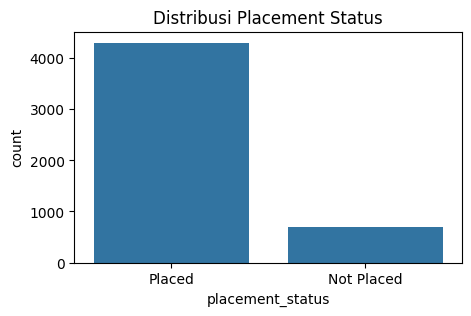

In [ ]:
print(df['placement_status'].value_counts())

plt.figure(figsize=(5, 3))
sns.countplot(x='placement_status', data=df)
plt.title('Distribusi Placement Status')
plt.show()

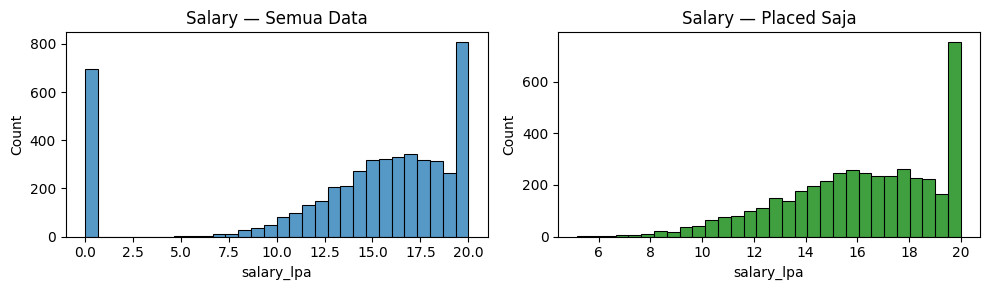

Salary = 0 untuk Not Placed: True


In [7]:
# Distribusi salary
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
sns.histplot(df['salary_lpa'], bins=30)
plt.title('Salary — Semua Data')

plt.subplot(1, 2, 2)
sns.histplot(df[df['placement_status']=='Placed']['salary_lpa'], bins=30, color='green')
plt.title('Salary — Placed Saja')

plt.tight_layout()
plt.show()

print('Salary = 0 untuk Not Placed:', (df[df['placement_status']=='Not Placed']['salary_lpa']==0).all())

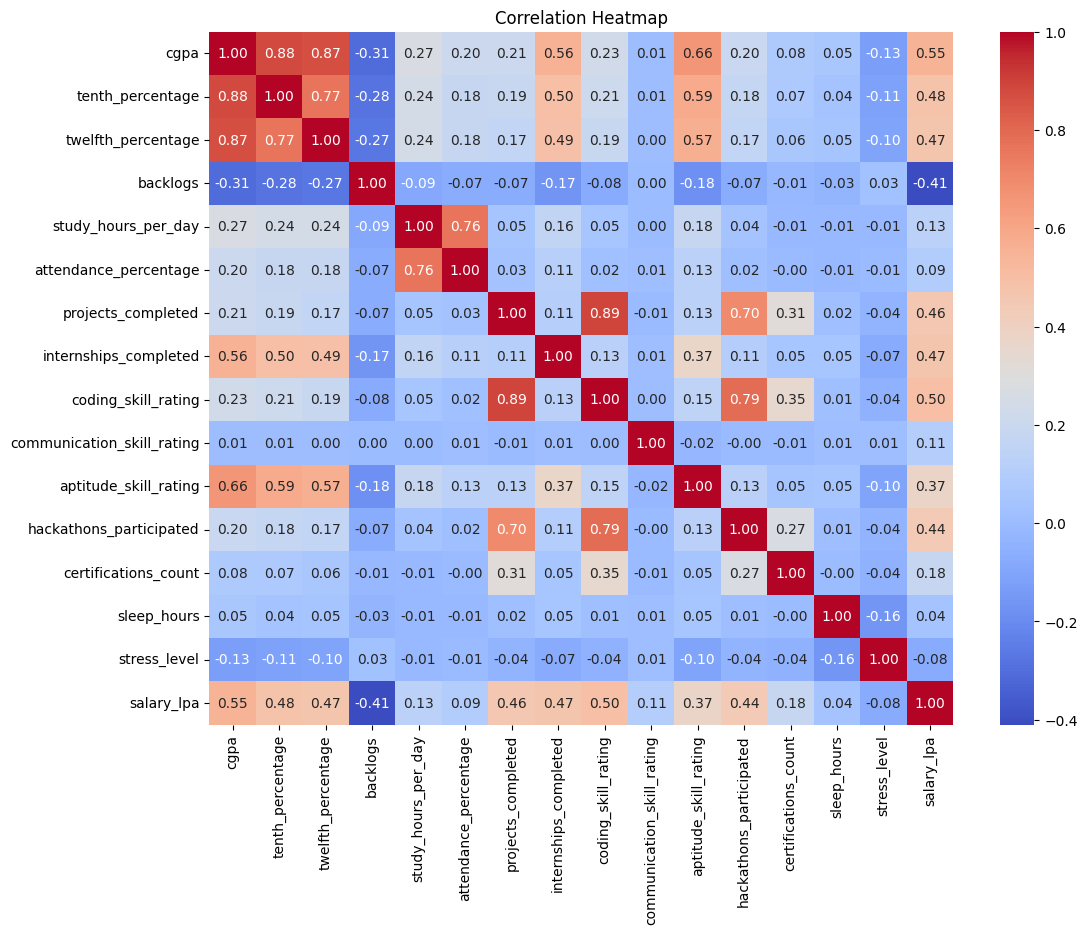

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

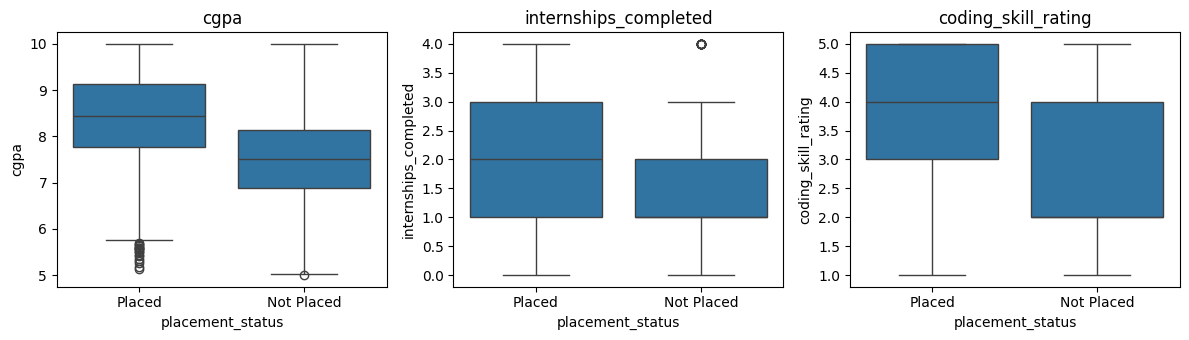

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ['cgpa', 'internships_completed', 'coding_skill_rating']):
    sns.boxplot(x='placement_status', y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Bikin dua fitur gabungan :
- `academic_score` — rata-rata nilai akademik (CGPA dikali 10 biar skalanya sama dengan persen).
- `skill_avg` — rata-rata tiga skill rating.

In [10]:
df['academic_score'] = (df['cgpa']*10 + df['tenth_percentage'] + df['twelfth_percentage']) / 3
df['skill_avg']      = (df['coding_skill_rating'] + df['communication_skill_rating'] + df['aptitude_skill_rating']) / 3

df[['academic_score', 'skill_avg']].describe()

,academic_score,skill_avg
count,5000.000000,5000.000000
mean,77.306147,3.623467
std,9.635063,0.697908
min,50.066667,1.333333
25%,70.758333,3.000000
50%,77.566667,3.666667
75%,84.400000,4.000000
max,98.566667,5.000000


## 5. Preprocessing Pipeline

Numeric: isi NaN pakai median, lalu StandardScaler.  
Categorical: isi NaN pakai `'Unknown'`, lalu OneHotEncoder.

Semua masuk ke `ColumnTransformer` biar konsisten dan aman dari data leakage.

In [11]:
num_features = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
                'projects_completed', 'internships_completed',
                'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating',
                'hackathons_participated', 'certifications_count',
                'stress_level',
                'academic_score', 'skill_avg']

cat_features = ['branch', 'city_tier', 'extracurricular_involvement']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
])

## 6. Train / Test Split

- Klasifikasi: pakai semua data, split 80/20 dengan `stratify`.
- Regresi: cuma siswa yang Placed (salary ≠ 0), split 80/20.

In [12]:
# Klasifikasi
X_cls = df.drop(columns=['placement_status', 'salary_lpa'])
y_cls = df['placement_status']

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=42)

print('Train:', X_cls_train.shape, ' Test:', X_cls_test.shape)

Train: (4000, 24)  Test: (1000, 24)


In [13]:
# Regresi (Placed saja)
placed = df[df['placement_status']=='Placed']
X_reg = placed.drop(columns=['placement_status', 'salary_lpa'])
y_reg = placed['salary_lpa']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print('Train:', X_reg_train.shape, ' Test:', X_reg_test.shape)

Train: (3442, 24)  Test: (861, 24)


## 7. Klasifikasi — 3 Model dengan Hyperparameter Tuning
Menggunakan Logistic Regression, Random Forest, dan Gradient Boosting.  
Tiap model di-tune pakai GridSearchCV, 10-fold CV
tiap model tuning 3 hyperparameter.

In [14]:
# Logistic Regression
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42)),
])

lr_params = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__max_iter': [500, 1000],
}

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=10, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_cls_train, y_cls_train)

print('LR best params:', lr_grid.best_params_)
print('LR best CV f1_macro:', round(lr_grid.best_score_, 4))
lr_best = lr_grid.best_estimator_

LR best params: {'model__C': 0.1, 'model__max_iter': 500, 'model__solver': 'lbfgs'}
LR best CV f1_macro: 0.7335


In [15]:
# Random Forest
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)),
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

rf_grid = GridSearchCV(rf_pipe, rf_params, cv=10, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_cls_train, y_cls_train)

print('RF best params:', rf_grid.best_params_)
print('RF best CV f1_macro:', round(rf_grid.best_score_, 4))
rf_best = rf_grid.best_estimator_

RF best params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
RF best CV f1_macro: 0.735


In [16]:
# Gradient Boosting
gb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42)),
])

gb_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5],
}

gb_grid = GridSearchCV(gb_pipe, gb_params, cv=10, scoring='f1_macro', n_jobs=-1)
gb_grid.fit(X_cls_train, y_cls_train)

print('GB best params:', gb_grid.best_params_)
print('GB best CV f1_macro:', round(gb_grid.best_score_, 4))
gb_best = gb_grid.best_estimator_

GB best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
GB best CV f1_macro: 0.739


In [17]:
# Ringkasan CV score classifier
print(f'LR  CV f1_macro = {lr_grid.best_score_:.4f}')
print(f'RF  CV f1_macro = {rf_grid.best_score_:.4f}')
print(f'GB  CV f1_macro = {gb_grid.best_score_:.4f}')

LR  CV f1_macro = 0.7335
RF  CV f1_macro = 0.7350
GB  CV f1_macro = 0.7390


In [18]:
# Evaluasi di test set
def evaluate_clf(model, name):
    pred = model.predict(X_cls_test)
    proba = model.predict_proba(X_cls_test)[:, list(model.classes_).index('Placed')]
    return {
        'accuracy': accuracy_score(y_cls_test, pred),
        'f1_macro': f1_score(y_cls_test, pred, average='macro'),
        'roc_auc':  roc_auc_score((y_cls_test=='Placed').astype(int), proba),
    }

cls_results = {
    'LogisticRegression': evaluate_clf(lr_best, 'LogisticRegression'),
    'RandomForest':       evaluate_clf(rf_best, 'RandomForest'),
    'GradientBoosting':   evaluate_clf(gb_best, 'GradientBoosting'),
}

cls_df = pd.DataFrame(cls_results).T.round(4)
cls_df

,accuracy,f1_macro,roc_auc
LogisticRegression,0.838,0.7488,0.9127
RandomForest,0.869,0.7335,0.8931
GradientBoosting,0.880,0.7199,0.8977


Model terpilih: LogisticRegression
(Catatan: ketiganya performanya cukup dekat, pilihan bisa berubah tergantung metrik yang diprioritaskan.)

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.46      0.87      0.60       139
      Placed       0.98      0.83      0.90       861

    accuracy                           0.84      1000
   macro avg       0.72      0.85      0.75      1000
weighted avg       0.90      0.84      0.86      1000



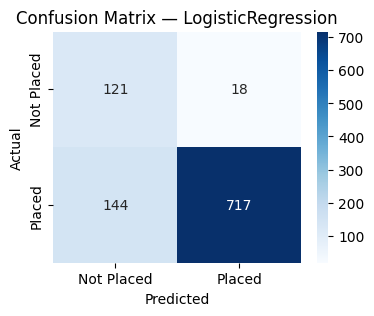

In [ ]:
# Detail model terbaik (pilih by f1_macro, tapi selisihnya tipis — bisa diganti)
best_cls_name = cls_df['f1_macro'].idxmax()
best_cls_model = {'LogisticRegression': lr_best, 'RandomForest': rf_best,
                  'GradientBoosting': gb_best}[best_cls_name]
print(f'Model terpilih: {best_cls_name}')

pred = best_cls_model.predict(X_cls_test)
print('\nClassification Report:')
print(classification_report(y_cls_test, pred))

cm = confusion_matrix(y_cls_test, pred, labels=['Not Placed', 'Placed'])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_cls_name}')
plt.show()

Karena kelas tidak seimbang, `f1_macro` lebih informatif dibanding accuracy. Tapi selisih antar model kadang tipis, jadi pilihan final tergantung metrik mana yang mau diprioritaskan (misal: kalau mau prioritas recall siswa Not Placed, lihat nilai recall-nya).

## 8. Regresi — 3 Model dengan Hyperparameter Tuning

Ridge, Random Forest Regressor, dan Gradient Boosting Regressor.  
model di-tune pakai GridSearchCV, 10-fold CV, scoring = `neg_root_mean_squared_error` supaya RMSE-nya bisa langsung dibandingkan.  
model tuning 3 hyperparameter.

In [20]:
# Ridge
ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge()),
])

ridge_params = {
    'model__alpha': [0.1, 1, 10],
    'model__solver': ['auto', 'cholesky', 'lsqr'],
    'model__fit_intercept': [True, False],
}

ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=10,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_reg_train, y_reg_train)

print('Ridge best params:', ridge_grid.best_params_)
print('Ridge best CV RMSE:', round(-ridge_grid.best_score_, 4))
ridge_best = ridge_grid.best_estimator_

Ridge best params: {'model__alpha': 1, 'model__fit_intercept': True, 'model__solver': 'auto'}
Ridge best CV RMSE: 1.3721


In [21]:
# Random Forest Regressor
rfr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rfr_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

rfr_grid = GridSearchCV(rfr_pipe, rfr_params, cv=10,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
rfr_grid.fit(X_reg_train, y_reg_train)

print('RF Regressor best params:', rfr_grid.best_params_)
print('RF Regressor best CV RMSE:', round(-rfr_grid.best_score_, 4))
rfr_best = rfr_grid.best_estimator_

RF Regressor best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
RF Regressor best CV RMSE: 1.4697


In [22]:
# Gradient Boosting Regressor
gbr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42)),
])

gbr_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5],
}

gbr_grid = GridSearchCV(gbr_pipe, gbr_params, cv=10,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
gbr_grid.fit(X_reg_train, y_reg_train)

print('GB Regressor best params:', gbr_grid.best_params_)
print('GB Regressor best CV RMSE:', round(-gbr_grid.best_score_, 4))
gbr_best = gbr_grid.best_estimator_

GB Regressor best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
GB Regressor best CV RMSE: 1.3731


In [23]:
# Ringkasan CV score regressor
print(f'Ridge CV RMSE = {-ridge_grid.best_score_:.4f}')
print(f'RF    CV RMSE = {-rfr_grid.best_score_:.4f}')
print(f'GB    CV RMSE = {-gbr_grid.best_score_:.4f}')

Ridge CV RMSE = 1.3721
RF    CV RMSE = 1.4697
GB    CV RMSE = 1.3731


In [24]:
def evaluate_reg(model):
    pred = model.predict(X_reg_test)
    return {
        'rmse': np.sqrt(mean_squared_error(y_reg_test, pred)),
        'mae':  mean_absolute_error(y_reg_test, pred),
        'r2':   r2_score(y_reg_test, pred),
    }

reg_results = {
    'Ridge':            evaluate_reg(ridge_best),
    'RandomForest':     evaluate_reg(rfr_best),
    'GradientBoosting': evaluate_reg(gbr_best),
}

reg_df = pd.DataFrame(reg_results).T.round(4)
reg_df

,rmse,mae,r2
Ridge,1.4044,1.1295,0.7725
RandomForest,1.4811,1.1766,0.7470
GradientBoosting,1.4065,1.1110,0.7718


Model regresi terpilih: Ridge


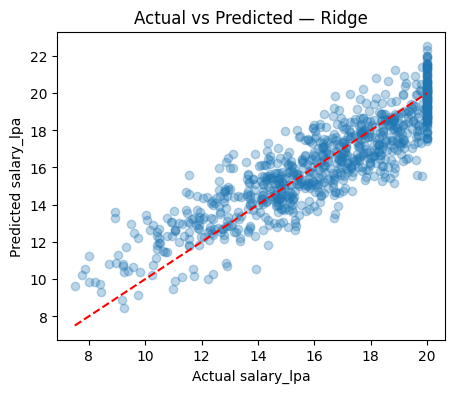

In [25]:
best_reg_name = reg_df['rmse'].idxmin()
best_reg_model = {'Ridge': ridge_best, 'RandomForest': rfr_best,
                  'GradientBoosting': gbr_best}[best_reg_name]
print(f'Model regresi terpilih: {best_reg_name}')

pred = best_reg_model.predict(X_reg_test)
plt.figure(figsize=(5, 4))
plt.scatter(y_reg_test, pred, alpha=0.3)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.xlabel('Actual salary_lpa'); plt.ylabel('Predicted salary_lpa')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.show()

## 9. Save Best Models

In [26]:
joblib.dump(best_cls_model, 'artifacts/classification_best.pkl')
joblib.dump(best_reg_model, 'artifacts/regression_best.pkl')

print('Saved:')
print('  artifacts/classification_best.pkl —', best_cls_name)
print('  artifacts/regression_best.pkl     —', best_reg_name)

Saved:
  artifacts/classification_best.pkl — LogisticRegression
  artifacts/regression_best.pkl     — Ridge


## 10. Summary

- Dataset 5.000 baris, hanya `extracurricular_involvement` yang punya NaN → diisi `'Unknown'`.
- Kelas tidak seimbang (86% Placed) → pakai `stratify` + `class_weight='balanced'` + f1_macro.
- `salary_lpa = 0` untuk semua Not Placed → regresi hanya pakai subset Placed.
- 2 fitur gabungan sederhana: `academic_score` & `skill_avg`.
- 3 model klasifikasi + 3 model regresi, semuanya ditune via GridSearchCV.
- Model terbaik disimpan ke `.pkl` untuk dipakai di Part 2 (MLflow) & Part 3–4 (deployment).